In [5]:
# SECTION 1: Load the data
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_excel('financialdata.xlsx')
df.head()

Saving financialdata.xlsx to financialdata (1).xlsx


,Sr.NO,shortName,industry,ebitdaMargins,profitMargins,grossMargins,operatingCashflow,revenueGrowth,operatingMargins,ebitda,...,sharesOutstanding,bookValue,trailingEps,priceToBook,heldPercentInsiders,enterpriseValue,earningsQuarterlyGrowth,pegRatio,forwardPE,marketCap
0,0,Apple Inc.,Consumer Electronics,0.33891,0.26579,0.43019,1.122410e+11,0.112,0.30900,128217997312,...,1.631940e+10,4.402,6.015,39.691050,0.00070,2910217830400,0.204,1.90,26.634148,2.851326e+12
1,1,Microsoft Corporation,Software—Infrastructure,0.49123,0.38498,0.68826,8.390900e+10,0.201,0.42524,90829996032,...,7.496870e+09,21.335,9.389,14.233889,0.00059,2231653367808,0.214,1.87,28.249302,2.276649e+12
2,2,Alphabet Inc.,Internet Content & Information,0.35377,0.29512,0.56940,9.165200e+10,0.324,0.30552,91144003584,...,3.156390e+08,380.044,112.197,7.447638,0.00034,1759692062720,0.356,1.22,20.802807,1.872632e+12
3,3,Alphabet Inc.,Internet Content & Information,0.35377,0.29512,0.56940,9.165200e+10,0.324,0.30552,91144003584,...,3.007550e+08,380.044,112.197,7.455610,0.07702,1761694842880,0.356,1.22,20.841927,1.871194e+12
4,4,"Amazon.com, Inc.",Internet Retail,0.12595,0.07101,0.42032,4.632700e+10,0.094,0.05295,59174998016,...,5.088440e+08,271.601,64.810,12.133496,0.09884,1720271503360,0.983,1.93,45.236378,1.676880e+12


In [7]:
# SECTION 2: Auto-detect the right column names
# (This is the fix for the errors you've been hitting — instead of
#  guessing exact column names, we search for them by keyword.)
def find_column(df, keywords):
    """Finds a column containing ALL the given keywords (case-insensitive)."""
    for col in df.columns:
        if all(k.lower() in col.lower() for k in keywords):
            return col
    return None

company_col = find_column(df, ['company']) or find_column(df, ['name']) or find_column(df, ['ticker'])
roe_col = find_column(df, ['roe']) or find_column(df, ['return', 'equity'])
current_ratio_col = find_column(df, ['current', 'ratio'])
debt_equity_col = find_column(df, ['debt', 'equity'])

print("\nDetected columns:")
print("Company:", company_col)
print("ROE:", roe_col)
print("Current Ratio:", current_ratio_col)
print("Debt to Equity:", debt_equity_col)

# If any of these print as "None", stop here and paste me the column list —
# it means the dataset uses a name I couldn't guess automatically.


Detected columns:
Company: shortName
ROE: returnOnEquity
Current Ratio: currentRatio
Debt to Equity: debtToEquity


In [9]:
# SECTION 3: Basic exploration
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sr.NO                    226 non-null    int64  
 1   shortName                226 non-null    object 
 2   industry                 226 non-null    object 
 3   ebitdaMargins            226 non-null    float64
 4   profitMargins            226 non-null    float64
 5   grossMargins             226 non-null    float64
 6   operatingCashflow        220 non-null    float64
 7   revenueGrowth            226 non-null    float64
 8   operatingMargins         226 non-null    float64
 9   ebitda                   226 non-null    int64  
 10  grossProfits             226 non-null    int64  
 11  freeCashflow             219 non-null    float64
 12  currentPrice             226 non-null    float64
 13  earningsGrowth           193 non-null    float64
 14  currentRatio             2

,Sr.NO,ebitdaMargins,profitMargins,grossMargins,operatingCashflow,revenueGrowth,operatingMargins,ebitda,grossProfits,freeCashflow,...,sharesOutstanding,bookValue,trailingEps,priceToBook,heldPercentInsiders,enterpriseValue,earningsQuarterlyGrowth,pegRatio,forwardPE,marketCap
count,226.000000,226.000000,226.000000,226.000000,2.200000e+02,226.000000,226.000000,2.260000e+02,2.260000e+02,2.190000e+02,...,2.240000e+02,224.000000,224.000000,207.000000,226.000000,2.260000e+02,194.000000,221.000000,224.000000,2.240000e+02
mean,122.389381,0.303436,0.169914,0.487156,8.535650e+09,0.356938,0.227639,1.002093e+10,1.683568e+10,5.064281e+09,...,9.208130e+08,38.024888,8.528768,11.203615,0.027760,1.715289e+11,1.390149,1.743575,25.412563,1.527259e+11
std,69.456613,0.161582,0.130988,0.213379,1.448165e+10,2.048120,0.133183,1.556694e+10,2.747796e+10,9.677779e+09,...,1.503073e+09,52.022517,14.629248,25.066822,0.072991,3.210952e+11,8.244478,4.417592,17.839710,3.238562e+11
min,0.000000,0.013680,-0.073000,0.050300,-3.416000e+09,-0.197000,-0.008110,4.471000e+08,-5.748770e+08,-2.446687e+10,...,2.063440e+07,-102.774000,-30.589000,0.740042,0.000070,2.759148e+10,-0.996000,-43.470000,1.067773,3.352149e+10
25%,63.250000,0.181082,0.085913,0.323420,2.337757e+09,0.078500,0.140363,2.999175e+09,4.287000e+09,1.276746e+09,...,2.733227e+08,11.536500,2.825750,2.789795,0.001395,5.145912e+10,-0.003750,1.040000,15.537212,4.373719e+10
50%,124.500000,0.283050,0.146095,0.482930,4.132824e+09,0.132000,0.209065,5.385000e+09,7.822800e+09,2.597000e+09,...,5.126055e+08,26.829500,5.311000,5.299363,0.002825,8.356014e+10,0.265000,1.750000,20.575026,6.614670e+10
75%,181.750000,0.409050,0.227272,0.656082,8.748500e+09,0.242500,0.308623,1.028200e+10,1.766875e+10,5.855869e+09,...,9.611212e+08,45.840750,9.358250,11.777579,0.009410,1.695614e+11,0.754500,2.790000,28.519979,1.349175e+11
max,240.000000,0.841330,1.070490,1.000000,1.122410e+11,30.650000,0.664520,1.282180e+11,1.974780e+11,8.015325e+10,...,1.631940e+10,380.044000,112.197000,314.135470,0.526090,2.910218e+12,111.333000,17.380000,132.864640,2.851326e+12


                      shortName  returnOnEquity
158        McKesson Corporation       14.017540
15       Home Depot, Inc. (The)       12.403111
154   O'Reilly Automotive, Inc.        7.173670
50       Lowe's Companies, Inc.        6.578290
92         HCA Healthcare, Inc.        4.743920
79           Altria Group, Inc.        2.711980
190  Kimberly-Clark Corporation        2.296390
123   Colgate-Palmolive Company        2.256760
155              Autodesk, Inc.        1.955530
0                    Apple Inc.        1.455670


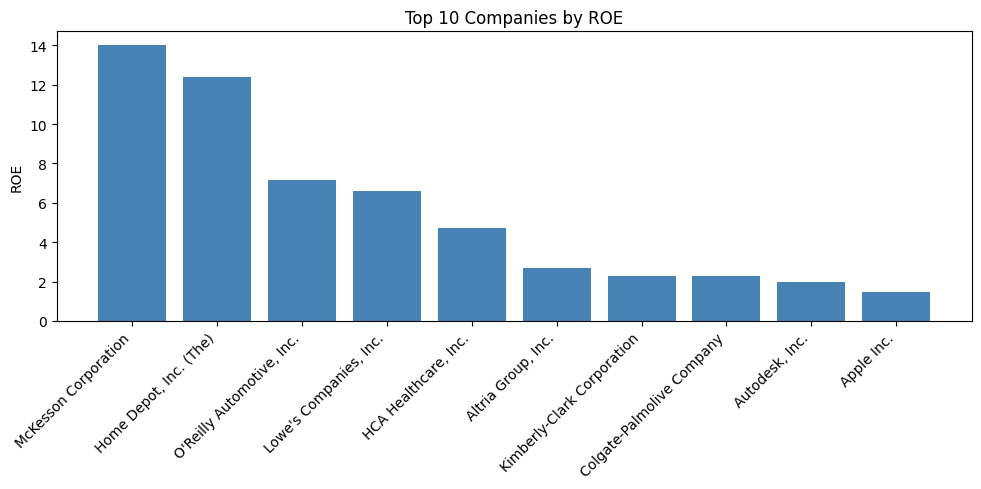

In [11]:
# SECTION 4: Top 10 by ROE
top10_roe = df.sort_values(by=roe_col, ascending=False).head(10)
print(top10_roe[[company_col, roe_col]])

plt.figure(figsize=(10,5))
plt.bar(top10_roe[company_col], top10_roe[roe_col], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Companies by ROE')
plt.ylabel('ROE')
plt.tight_layout()
plt.show()

                           shortName  currentRatio
6                 NVIDIA Corporation         7.145
121         Activision Blizzard, Inc         5.561
42    Texas Instruments Incorporated         5.327
74          Intuitive Surgical, Inc.         5.083
171            Arista Networks, Inc.         5.064
206     Transdigm Group Incorporated         5.059
160                     DexCom, Inc.         4.975
182     Monster Beverage Corporation         4.702
120  Vertex Pharmaceuticals Incorpor         4.625
83                       Zoetis Inc.         3.856


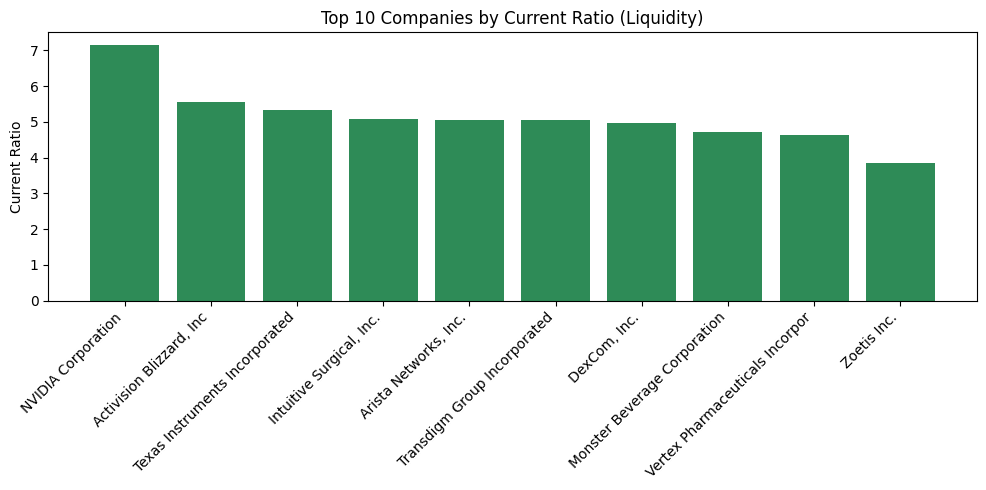

In [13]:
# SECTION 5: Top 10 by Current Ratio (liquidity)
top10_liquidity = df.sort_values(by=current_ratio_col, ascending=False).head(10)
print(top10_liquidity[[company_col, current_ratio_col]])

plt.figure(figsize=(10,5))
plt.bar(top10_liquidity[company_col], top10_liquidity[current_ratio_col], color='seagreen')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Companies by Current Ratio (Liquidity)')
plt.ylabel('Current Ratio')
plt.tight_layout()
plt.show()

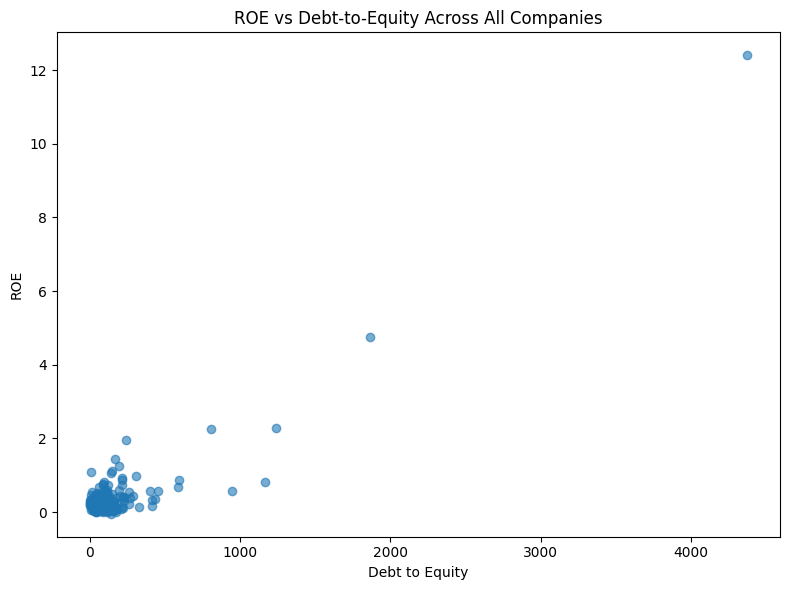

In [14]:
# SECTION 6: ROE vs Debt-to-Equity (context check across ALL companies)
plt.figure(figsize=(8,6))
plt.scatter(df[debt_equity_col], df[roe_col], alpha=0.6)
plt.xlabel('Debt to Equity')
plt.ylabel('ROE')
plt.title('ROE vs Debt-to-Equity Across All Companies')
plt.tight_layout()
plt.show()

Financial Statement Analysis — Top 200 US Companies

Loaded a dataset of pre-calculated ratios (ROE, current ratio, debt-to-equity, etc.) for 200 US companies.
Ranked companies by ROE — McKesson Corporation topped the list.
High ROE isn't always "good performance" — it can be inflated by low or negative equity (e.g. from heavy stock buybacks), so ROE should always be checked alongside debt levels, not read in isolation.